
## 9.1 Diagrammatic notation for tensor networks

* $\rightarrow$ simplifies notation a lot
* $\rightarrow$ new language (like Feynman diagrams)
  
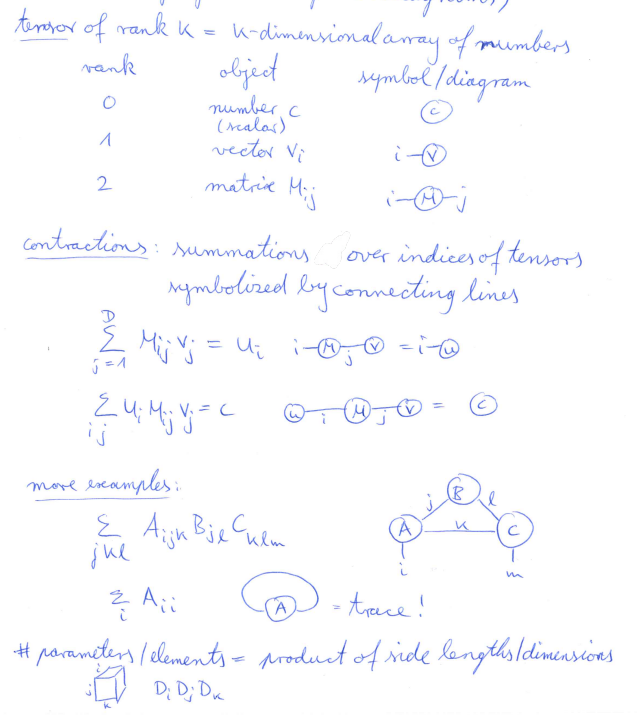

## 9.2 Limited entanglement of MPS

Write out the MPS ansatz for the $N$ spin-1/2 wave function:

$$|\psi\rangle = \sum_{i_1 \dots i_N} c_{i_1 \dots i_N} |i_1 \dots i_N\rangle \quad \left(i_k \in \{0,1\}\right)$$
*(generally $i_k \in \{0, \dots, d-1\}$, where $d = \text{local dimension}$)*

$$\implies |\psi\rangle = \sum_{i_1 \dots i_N} \sum_{\alpha_1 \dots \alpha_{N-1}} A_{\alpha_1}^{[1] i_1} A_{\alpha_1 \alpha_2}^{[2] i_2} \dots A_{\alpha_{N-1}}^{[N] i_N} |i_1 \dots i_N\rangle \quad \text{(MPS ansatz)}$$

### Diagrammatic View:
* **Top:** A full rank-$N$ coefficient tensor $c$ with open indices $i_1, i_2, \dots, i_N$.
* **Bottom:** The factorized MPS chain of tensors $A^{[1]}, A^{[2]}, \dots, A^{[N]}$ connected via virtual bond indices $\alpha_k$ and displaying open physical legs $i_1, i_2, \dots, i_N$.

### Split into system $A$ and system $B$:

$$= \sum_{\substack{i_1 \dots i_k \\ i_{k+1} \dots i_N}} \sum_{\alpha_1 \dots \alpha_k \dots \alpha_{N-1}} A_{\alpha_1}^{[1] i_1} \dots A_{\alpha_{k-1} \alpha_k}^{[k] i_k} A_{\alpha_k \alpha_{k+1}}^{[k+1] i_{k+1}} \dots A_{\alpha_{N-1}}^{[N] i_N} \underbrace{|i_1 \dots i_k\rangle}_{A} \underbrace{|i_{k+1} \dots i_N\rangle}_{B}$$

Grouping into states localized on partition $A$ and partition $B$:

$$= \sum_{\alpha_k} \underbrace{\left( \sum_{\substack{i_1 \dots i_k \\ \alpha_1 \dots \alpha_{k-1}}} A_{\alpha_1}^{[1] i_1} \dots A_{\alpha_{k-1} \alpha_k}^{[k] i_k} |i_1 \dots i_k\rangle \right)}_{\text{states on } A}$$

$$\otimes \underbrace{\left( \sum_{\substack{i_{k+1} \dots i_N \\ \alpha_{k+1} \dots \alpha_{N-1}}} A_{\alpha_k \alpha_{k+1}}^{[k+1] i_{k+1}} \dots A_{\alpha_{N-1}}^{[N] i_N} |i_{k+1} \dots i_N\rangle \right)}_{\text{states on } B}$$

$$= \sum_{\alpha_k=1}^{D} |\phi_{\alpha_k}^A\rangle \otimes |\phi_{\alpha_k}^B\rangle$$

* $\rightarrow$ **Almost a Schmidt decomposition**, but the states $|\phi_{\alpha_k}\rangle$ are not orthonormal yet.
* $\rightarrow$ **Maximal Schmidt rank $= D$**, which corresponds to the **"bond dimension"**.
* $\rightarrow$ The set of states $\{|\phi_{\alpha_k}^A\rangle \otimes |\phi_{\alpha_k}^B\rangle\}$ can be orthonormalized to obtain the standard canonical form of the Schmidt decomposition via Singular Value Decomposition (**SVD**):

$$|\psi\rangle = \sum_{k} \lambda_k |\tilde{\phi}_k^A\rangle \otimes |\tilde{\phi}_k^B\rangle$$

* $\rightarrow$ **Largest entanglement entropy?**
  Reached for $\lambda_k = \frac{1}{\sqrt{D}}$
  $$\implies S_E = -\sum_{k} \lambda_k^2 \log \lambda_k^2 \le -\sum_{k} \frac{1}{D} \log \frac{1}{D} = \log D$$

* $\rightarrow$ **Compressed representation!**
  **Parameter counting:** $A_{\alpha_{k-1} \alpha_k}^{[k] i_k}$ : $N$ rank-3 tensors *(except boundary tensors which are rank-2)*.
  * $i_k = 1 \dots d$ *(local dim. $= 2$ for spin-1/2)*
  * $\alpha_k = 1 \dots D$ *(bond dimension, can in principle vary between different $k$, but in practice homogeneous)*
  
  $$\implies \text{\# parameters} = N \cdot D^2 \cdot d \ll d^N \quad \text{(original coefficient tensor form } c_{i_1 \dots i_N}\text{)}$$

  ## 9.3 Periodic boundary conditions

Often considered in spin Hamiltonians *(maybe because these are the cases for which analytical solutions exist sometimes...)*.

* $\rightarrow$ **Add a bond between spins $1$ and $N$:** *(As sketched in the diagram, the boundary tensors at the ends of the chain are linked by a virtual bond loops back around.)*

$$c_{i_1 \dots i_N} = \sum_{\alpha_1 \dots \alpha_N} A_{\alpha_N \alpha_1}^{[1] i_1} A_{\alpha_1 \alpha_2}^{[2] i_2} \dots A_{\alpha_{N-1} \alpha_N}^{[N] i_N}$$

$$= \sum_{\alpha_N} M_{\alpha_N \alpha_N}^{i_1 \dots i_N} = \text{tr}\left[ A^{[1] i_1} A^{[2] i_2} \dots A^{[N] i_N} \right]$$

* $\rightarrow$ **Matrix multiplications + trace** *(where the tensors can be viewed as vectors of $D \times D$ matrices)*.
* $\rightarrow$ Can also set all tensors to the same $A^{[j]} = A$ for **translation invariant systems** *(which are often considered)*.
* $\rightarrow$ *Note: reduces to open boundary conditions (OBC) if the bond dimension of $\alpha_N$ is set to 1.*

## 9.4 Calculating observables efficiently

Any observable can be written as

$$O = \sum_{j_1 \dots j_N} C_{j_1 \dots j_N} O_{j_1} \otimes O_{j_2} \otimes \dots \otimes O_{j_N}$$

> **Note:** $O_{j_k}$ are local operators where $j_k \in \{1 \dots d^2\}$ (the dimension of a complete set of operators, e.g., $\{\mathbb{1}, \sigma_x, \sigma_y, \sigma_z\}$ for spin-1/2).

For typical observables, this sum only has **few terms** ($\hat{=}$ few-body operators):

* **Magnetization of spin #1:**  
  $$S_x^{(1)} = S_x \otimes \mathbb{1} \otimes \dots \otimes \mathbb{1}$$

* **Spin-spin correlations:**  
  $$S_x^{(i)} S_x^{(j)} = \mathbb{1} \otimes \dots \otimes S_x^{(i)} \otimes \dots \otimes S_x^{(j)} \otimes \dots \otimes \mathbb{1}$$

### $\implies$ How to compute expectation values $\langle\psi|O|\psi\rangle$ for such product operators given the MPS representation of $|\psi\rangle$?
*(where $O = O_1 \otimes \dots \otimes O_N$)*

### "bra" state representation
*(considering periodic boundaries for generality)*

$$\langle\psi| = \sum_{\substack{i_1' \dots i_N' \\ \alpha_1' \dots \alpha_N'}} A_{\alpha_N' \alpha_1'}^{[1] i_1'*} \dots A_{\alpha_{N-1}' \alpha_N'}^{[N] i_N'*} \langle i_1' \dots i_N'|$$

### Computing the expectation value:

$$\langle\psi|O|\psi\rangle = \sum_{\substack{i_1 \dots i_N \\ \alpha_1 \dots \alpha_N}} \sum_{\substack{i_1' \dots i_N' \\ \alpha_1' \dots \alpha_N'}} A_{\alpha_N' \alpha_1'}^{[1] i_1'*} \dots A_{\alpha_{N-1}' \alpha_N'}^{[N] i_N'*} A_{\alpha_N \alpha_1}^{[1] i_1} \dots A_{\alpha_{N-1} \alpha_N}^{[N] i_N} \underbrace{\langle i_1' \dots i_N'| O | i_1 \dots i_N \rangle}_{\langle i_1'|O_1|i_1\rangle \dots \langle i_N'|O_N|i_N\rangle}$$

#### **Reorder sums!**

$$= \sum_{\substack{\alpha_1 \dots \alpha_N \\ \alpha_1' \dots \alpha_N'}} \underbrace{\sum_{i_1, i_1'} A_{\alpha_N' \alpha_1'}^{[1] i_1'*} A_{\alpha_N \alpha_1}^{[1] i_1} \langle i_1'|O_1|i_1\rangle}_{E_{O_1}^{[1]} \quad \text{(rank-4 tensors)}} \dots \underbrace{\sum_{i_N, i_N'} A_{\alpha_{N-1}' \alpha_N'}^{[N] i_N'*} A_{\alpha_{N-1} \alpha_N}^{[N] i_N} \langle i_N'|O_N|i_N\rangle}_{E_{O_N}^{[N]}}$$

### Diagrammatic notation of the local transfer operator $E_{O_1}^{[1]}$:

$$\begin{array}{rcccl}
\alpha_N & ─────── & \boxed{\phantom{\int} E_{O_1}^{[1]} \phantom{\int}} & ─────── & \alpha_1 \\
\alpha_N' & ─────── & & ─────── & \alpha_1'
\end{array}$$


Diagrammatic Representation of Observable Expectation Value

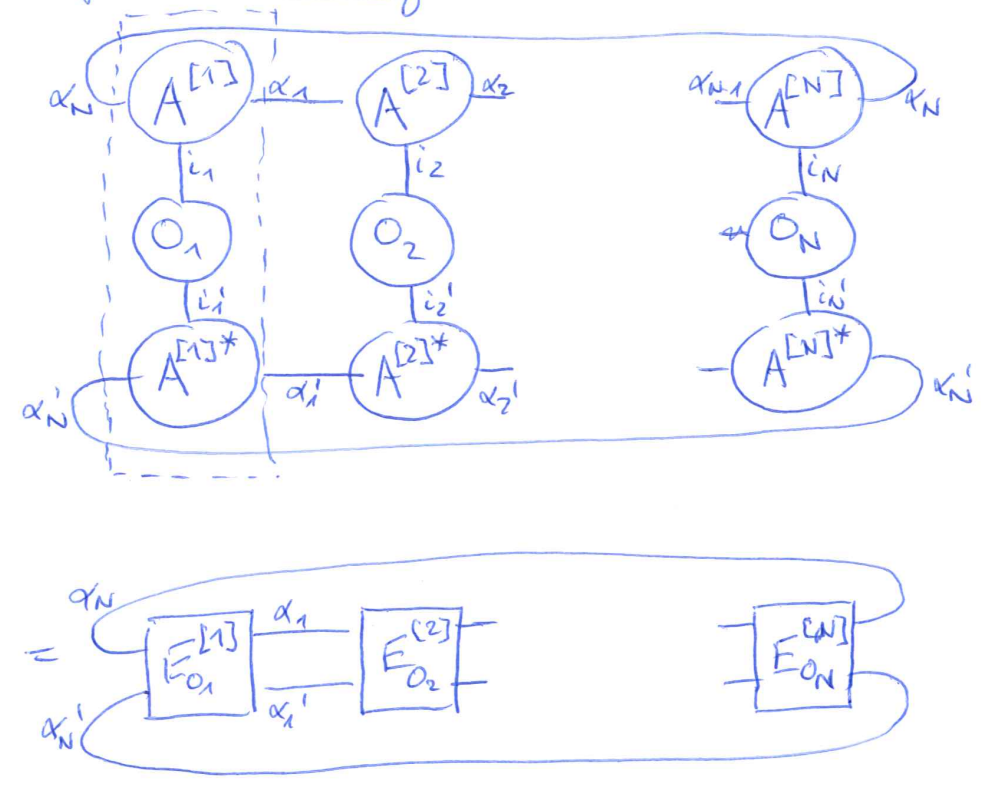

## 9.5 AKLT model &nbsp;&nbsp;&nbsp;&nbsp; *(Affleck, Lieb, Kennedy, Tasaki)*

This is a **spin-1 Heisenberg model** featuring a **"bi-quartic" spin interaction term**:

$$H = \sum_{j} \left[ \frac{1}{2} \vec{S}_j \cdot \vec{S}_{j+1} + \frac{1}{6} \left(\vec{S}_j \cdot \vec{S}_{j+1}\right)^2 + \frac{1}{3} \right]$$

### Key Characteristics & Physical Significance:

* **Haldane's Conjecture Testing:** It was originally introduced to rigorously test Haldane's conjecture, which states that antiferromagnetic Heisenberg chains of **integer spin** have an excitation gap, whereas **half-integer spin** chains are gapless in 1D.
* **Ground State Structure:** The ground state forms a **valence bond solid (VBS)**. Under periodic boundary conditions (PBC), this ground state is unique and strictly gapped.
* **Boundary Sensitivity:** Shifting to open boundary conditions (OBC) introduces a **4-fold degeneracy** in the ground state due to uncompensated effective spin-1/2 edge states.
* **Exact MPS Representation:** Crucially, this ground state can be expressed analytically as an exact Matrix Product State (MPS) with a very small bond dimension of **$D = 2$**.